# Molecular Dynamics with Neural Network Potentials

### Technical tutorial: from a quantum-chemistry dataset to nonadiabatic dynamics

**Prototype system:** the methylenimmonium cation, CH2NH2+ — the *minimal model of the retinal chromophore* and the standard benchmark for machine‑learned excited‑state dynamics.

---

**What you will do in the next ~50 minutes**

| min | section |
|----|---------|
| 0–8 | Theory: Born–Oppenheimer, conical intersections, photochemistry |
| 8–16 | MACE architecture and the excited‑state problem (X‑MACE) |
| 16–26 | The dataset: load and visualize the potential energy surfaces |
| 26–36 | Training a model |
| 36–48 | Nonadiabatic dynamics: surface hopping + results |
| 48–50 | Caveats, production workflow, extensions |


## Setup — Imports, dependencies, constants, and auxiliary functions

Run this cell **once** at the start. It:
1. Imports all required packages (numpy, matplotlib, ase, mace/X-MACE).
2. Defines physical constants and unit-conversion factors.
3. Defines **all** helper/server functions used throughout the notebook:
   - Data loading & parsing (`load_extxyz_multistate`, `synthetic_torsion_scan`)
   - Geometry helpers (`_dihedral`, `_rotate`)
   - Energy/force/NAC providers (MACE backend)
   - FSSH integrators
   - Learning-curve parser
   - Molecular-movie drawing helpers


## Environment

Two independent pieces:

- **Always‑on stack** (data viz + the surface‑hopping demo): `numpy`, `matplotlib`, `ase`. Installs in seconds, runs on a laptop.
- **X‑MACE stack** (training + ML inference): a GPU and the X‑MACE fork of MACE. Best installed *before* the session.

```bash

# --- X-MACE (do this beforehand; GPU recommended) ---
git clone https://github.com/rhyan10/X-MACE.git
cd X-MACE
git checkout X-MACE_socs
conda create -n x-mace-env python=3.13 -y && conda activate x-mace-env
pip install .
```

In [72]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     SETUP — run this cell first                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Standard library ─────────────────────────────────────────────────────────
import os, sys, glob, re, json, itertools, subprocess, time
import numpy as np

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ── Optional: ASE ────────────────────────────────────────────────────────────
try:
    HAVE_ASE = True
except Exception:
    HAVE_ASE = False

# ── Optional: X-MACE ────────────────────────────────────────────────────────
try:
    import mace
    HAVE_XMACE = True
except Exception:
    HAVE_XMACE = False

print(f"ASE available   : {HAVE_ASE}")
print(f"X-MACE available: {HAVE_XMACE}   (training/inference cells are guarded on this)")
np.random.seed(0)
plt.rcParams["figure.dpi"] = 120

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = "./data"
MODEL_DIR  = "./results/ch2nh2_demo"
os.makedirs(DATA_DIR, exist_ok=True)

# ── Physical constants & unit conversion ─────────────────────────────────────
HBAR = 0.6582119569       # eV·fs
KB   = 8.617333e-5        # eV/K
BOHR2ANG = 0.529177210903
# Positions in Bohr, forces in eV/Bohr, masses in AMU, time in fs.
CONV = 1.60218e-19 * 1e-30 / (5.29177e-11**2 * 1.66054e-27)   # ≈ 0.03445

MASSES_AMU     = np.array([12.011, 14.007, 1.008, 1.008, 1.008, 1.008])
ATOMIC_NUMBERS = np.array([6, 7, 1, 1, 1, 1])
N_STATES = 3
N_ATOMS  = 6

_COL = ['#0072B2', '#E69F00', '#009E73']
_LAB = ['S$_0$', 'S$_1$', 'S$_2$']

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     GEOMETRY HELPERS                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def _dihedral(R, a, b, c, d):
    """Signed dihedral angle a-b-c-d (radians), coordinates in any unit."""
    b1 = R[b]-R[a]; b2 = R[c]-R[b]; b3 = R[d]-R[c]
    n1 = np.cross(b1, b2); n2 = np.cross(b2, b3)
    n1 /= np.linalg.norm(n1); n2 /= np.linalg.norm(n2)
    m1 = np.cross(n1, b2/np.linalg.norm(b2))
    return np.arctan2(m1@n2, n1@n2)

def _dihedral_deg(R, a, b, c, d):
    # ── using _dihedral from setup, but need degrees version ──
    return np.degrees(_dihedral(R, a, b, c, d))

def _rotate(R, center, axis, deg, indices):
    """Rodrigues rotation of selected atoms around axis through center."""
    u = axis / np.linalg.norm(axis)
    th = np.radians(deg); c, s = np.cos(th), np.sin(th)
    K = np.array([[0,-u[2],u[1]],[u[2],0,-u[0]],[-u[1],u[0],0]])
    rot = c*np.eye(3) + s*K + (1-c)*np.outer(u,u)
    R2 = R.copy()
    for i in indices:
        R2[i] = center + rot @ (R[i] - center)
    return R2

def _read_scan_xyz(path):
    """Read a multi-frame .xyz file. Returns list of (comment, R_bohr) tuples."""
    with open(path) as f:
        lines = f.read().splitlines()
    frames = []
    i = 0
    while i < len(lines):
        nat = int(lines[i].strip())
        comment = lines[i + 1]
        R_ang = np.array([[float(v) for v in lines[i + 2 + j].split()[1:]]
                          for j in range(nat)])
        frames.append((comment, R_ang / BOHR2ANG))   # store in Bohr
        i += 2 + nat
    return frames

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     DATA LOADING & PARSING                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def load_extxyz_multistate(path, n_states=3, e_key="REF_energy"):
    """
    Parse extended-XYZ from X-MACE / ASE with energies stored as
      REF_energy="_JSON [[e0, e1, e2]]"  (values already in eV)
    Returns list of dicts: {Z, R (Bohr), E (eV rel. to S0 global min), phi (rad)}.
    CH2NH2+ atom order: C(0) N(1) H-C(2) H-N(3) H-N(4) H-C(5).
    phi = H(2)-C(0)=N(1)-H(3) torsion — measures the C=N twist.
    """
    frames = []
    with open(path) as fh:
        lines = fh.read().splitlines()
    pat = re.compile(rf'{e_key}="(?:_JSON\s*)?(\[\[.*?\]\])"')
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line: i += 1; continue
        try: nat = int(line)
        except ValueError: i += 1; continue
        E = None
        m = pat.search(lines[i+1])
        if m:
            E = np.array(json.loads(m.group(1))[0][:n_states])
        Z, R = [], []
        for j in range(nat):
            p = lines[i+2+j].split()
            Z.append(p[0]); R.append([float(p[1]), float(p[2]), float(p[3])])
        R = np.array(R)
        phi = _dihedral(R, 2, 0, 1, 3)
        frames.append({'Z': Z, 'R': R, 'E': E, 'phi': phi})
        i += 2 + nat
    Es = np.array([f['E'] for f in frames if f['E'] is not None])
    E0_min = Es[:, 0].min()
    for f in frames:
        if f['E'] is not None:
            f['E'] = f['E'] - E0_min
    return frames

def synthetic_torsion_scan(n=120, n_states=3):
    """Schematic S0/S1/S2 scan — used only when no XYZ file is present."""
    phi = np.linspace(0, np.pi, n)
    s2 = np.sin(phi)**2
    E0 = 2.5*s2
    d2 = 6.0 - 5.0*s2; lam = 0.2
    half = 0.5*(2.5*s2 - d2); root = np.sqrt(half**2 + lam**2)
    E1 = 0.5*(2.5*s2 + d2) + root
    E2 = 7.8 - 1.5*s2 + 0.3*np.cos(2*phi)
    return {'phi': phi, 'E': np.vstack([E0, E1, E2]).T}

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     LEARNING-CURVE PARSER                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def parse_learning_curve():
    for txtf in (glob.glob('./results/*/results/*_train.txt') +
                 glob.glob('./results/*_train.txt')):
        by_epoch = {}
        try:
            for line in open(txtf):
                try: d = json.loads(line)
                except: continue
                if d.get('mode') == 'eval' and d.get('epoch') is not None:
                    e = int(d['epoch'])
                    by_epoch.setdefault(e, []).append(d)
        except Exception:
            continue
        if not by_epoch:
            continue
        epochs, loss, mae_e, mae_f, mae_nac = [], [], [], [], []
        for ep in sorted(by_epoch):
            recs = by_epoch[ep]
            best = (next((r for r in recs if 'mae_nacs' in r), None)
                    or next((r for r in recs if 'mae_f'   in r), None)
                    or recs[0])
            epochs.append(ep)
            loss  .append(float(best['loss']))
            mae_e .append(float(best.get('mae_e_per_atom', float('nan'))) * 1e3)
            mae_f .append(float(best['mae_f']) * 1e3 if 'mae_f'   in best else float('nan'))
            mae_nac.append(float(best['mae_nacs'])     if 'mae_nacs' in best else float('nan'))
        if epochs:
            return (np.array(epochs), np.array(loss),
                    np.array(mae_e), np.array(mae_f), np.array(mae_nac), txtf)
    return None


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║              ENERGY / FORCE / NAC                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Backend A: ExcitedMACE ────────────────────────────────────────────────────
MACE_MODEL  = None
MACE_DEVICE = None
MACE_ZTABLE = None
MACE_CUTOFF = 5.0
MACE_HAS_NACS = False

def _load_mace_model(model_path):
    global MACE_MODEL, MACE_DEVICE, MACE_ZTABLE, MACE_HAS_NACS
    import torch
    from mace.data.utils import load_from_xyz
    from mace.tools import AtomicNumberTable

    device = (torch.device("mps") if torch.backends.mps.is_available()
               else torch.device("cpu"))
    model = torch.load(model_path, map_location=device, weights_only=False)
    model.eval()
    MACE_MODEL  = model
    MACE_DEVICE = device

    train_file = "./data/ch2nh2_with_forces.xyz"
    if not os.path.exists(train_file):
        train_file = "./data/ch2nh2.xyz"
    _, configs = load_from_xyz(
        train_file,
        config_type_weights={"Default": 1.0},
        energy_key="REF_energy",
        forces_key="REF_forces",
        nacs_key="REF_nacs",
    )
    MACE_ZTABLE = AtomicNumberTable(
        sorted(set(int(z) for c in configs[:1] for z in c.atomic_numbers))
    )
    print(f"ExcitedMACE loaded from {model_path} on {device}")
    print(f"  z-table: {MACE_ZTABLE.zs}")
    return True

def _get_EF_mace(R):
    """
    R: (n_atoms, 3) Bohr.
    Returns:
      E : (n_states,)                    eV
      F : (n_atoms, n_states, 3)         eV/Bohr
      D : (n_states, n_states, n_atoms, 3) Bohr^-1
    """
    import torch
    from mace.data.utils import Configuration
    from mace.data.atomic_data import AtomicData, get_data_loader

    config = Configuration(
        atomic_numbers=ATOMIC_NUMBERS,
        positions=R.astype(np.float64),
        energy=None, forces=None, nacs=None,
        cell=np.zeros((3, 3)), pbc=(False, False, False),
    )
    data   = AtomicData.from_config(config, z_table=MACE_ZTABLE, cutoff=MACE_CUTOFF)
    loader = get_data_loader([data], batch_size=1)
    batch  = next(iter(loader)).to(MACE_DEVICE)

    with torch.enable_grad():
        out = MACE_MODEL(batch, compute_force=True, compute_virials=False, compute_stress=False)

    E = out["energy"][0].detach().cpu().numpy()
    F = out["forces"].detach().cpu().numpy()

    D = np.zeros((N_STATES, N_STATES, N_ATOMS, 3))
    _first_call = not hasattr(_get_EF_mace, '_called')
    if _first_call:
        _get_EF_mace._called = True
        print(f'  [MACE output keys]: {list(out.keys())}')
    for key in ("NAC_values", "nac_values", "nacs", "NACs", "nacv", "nac"):
        if key in out and out[key] is not None:
            raw = out[key].detach().cpu().numpy()
            if _first_call:
                print(f'  [NAC] key=\'{key}\' shape={raw.shape} |raw|={float(np.sqrt(float(np.sum(raw**2)))):.4f}')
            if raw.ndim == 3:
                pairs = [(0,1),(0,2),(1,2)]
                for k,(i,j) in enumerate(pairs):
                    if k < raw.shape[1]:
                        D[i,j] =  raw[:, k, :]
                        D[j,i] = -raw[:, k, :]
            elif raw.ndim == 4:
                D = raw
            break
    return E, F, D

# ── Backend B: analytical 1D torsion (fallback) ─────────────────────────────
P1D = dict(A_G=2.5, E_EX=6.0, B_EX=5.0, LAMBDA=0.20, I_TORS=2000.0)

def _get_EF_1d(phi, p=P1D):
    s, c   = np.sin(phi), np.cos(phi)
    s2, ds2 = s*s, 2*s*c
    d1, d2   = p["A_G"]*s2, p["E_EX"] - p["B_EX"]*s2
    dd1, dd2 = p["A_G"]*ds2, -p["B_EX"]*ds2
    avg, half   = 0.5*(d1+d2), 0.5*(d1-d2)
    davg, dhalf = 0.5*(dd1+dd2), 0.5*(dd1-dd2)
    root  = np.sqrt(half*half + p["LAMBDA"]**2)
    droot = half*dhalf / root
    E = np.array([avg - root, avg + root])
    F = np.array([-(davg - droot), -(davg + droot)])
    num, den, dden = 2*p["LAMBDA"], (d1-d2), (dd1-dd2)
    d01 = 0.5*(-num*dden) / (num*num + den*den)
    return E, F, d01

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                ELECTRONIC PROPAGATION HELPERS                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def _sigma(D, V):
    """NAC coupling matrix: sigma_kj = sum D[k,j,atom,xyz] * V[atom,xyz]."""
    return np.einsum('kjax,ax->kj', D, V)

def _cdot_elec(cc, E, SIG):
    """RHS of TDSE: dc_k/dt = -i E_k/hbar c_k - sum_j sigma_kj c_j."""
    return (-1j / HBAR) * E * cc - SIG @ cc

def _rescale_velocity(V, D_kj, E_k, E_j, M):
    """Rescale velocity along NAC direction to conserve energy after hop."""
    d = D_kj.ravel()
    m = np.repeat(M, 3)
    v = V.ravel()
    A = np.sum(d**2 / m)
    B = np.dot(v, d)
    C = (E_j - E_k) * CONV
    disc = B**2 - 2.0 * A * C
    if disc < 0.0:
        return None
    sq = np.sqrt(disc)
    d1, d2 = (-B + sq) / A, (-B - sq) / A
    delta = d1 if abs(d1) < abs(d2) else d2
    return (v + delta * d / m).reshape(V.shape)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     FSSH INTEGRATORS                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def _find_fc_geometry(dataset):
    """Return the S0-minimum geometry from the dataset (Franck-Condon point)."""
    _fr = [f for f in dataset.get('frames', []) if f['E'] is not None]
    if not _fr:
        raise RuntimeError('Dataset not loaded; run Part 4 first.')
    _Es = np.array([f['E'] for f in _fr])
    return np.array(_fr[int(np.argmin(_Es[:, 0]))]['R'])

def run_fssh_3d(seed=0, dt=0.1, nsteps=1000, start_state=1, temp=300.0, tau_T=50.0, F_clamp=5.0, n_sub=20):
    """Full-dimensional FSSH on CH2NH2+."""
    rng   = np.random.default_rng(seed)
    M     = MASSES_AMU
    M3    = M[:, None]
    kT    = KB * temp
    n_dof = 3 * N_ATOMS - 3

    R  = _find_fc_geometry(dataset) + rng.normal(0, 0.02, (N_ATOMS, 3))
    V  = rng.normal(0, np.sqrt(kT * CONV / M3), (N_ATOMS, 3))
    V -= (M3 * V).sum(axis=0) / M.sum()

    active = start_state
    cvec   = np.zeros(N_STATES, complex); cvec[active] = 1.0
    E_shift = None

    t_list, R_list, PHI_list, ACT_list, E_list = [], [], [], [], []

    E, F_raw, D = _get_EF_mace(R)
    E_shift = E[0]

    for step in range(nsteps):
        F_act = np.clip(F_raw[:, active, :], -F_clamp, F_clamp)
        A_acc = CONV * F_act / M3
        V_half = V + 0.5 * A_acc * dt
        R_new  = R + V_half * dt

        try:
            E_new, F_new_raw, D_new = _get_EF_mace(R_new)
        except Exception:
            E_new, F_new_raw, D_new = E.copy(), F_raw.copy(), D.copy()
            R_new = R.copy()

        if not (np.isfinite(E_new).all() and np.isfinite(F_new_raw).all()):
            E_new, F_new_raw, D_new = E.copy(), F_raw.copy(), D.copy()
            R_new = R.copy()

        F_act_new = np.clip(F_new_raw[:, active, :], -F_clamp, F_clamp)
        V_new = V_half + 0.5 * CONV * F_act_new / M3 * dt

        KE    = 0.5 * np.sum(M3 * V_new**2) / CONV
        T_now = 2.0 * KE / (n_dof * KB) if KE > 1e-12 else temp
        lam   = float(np.clip(
            np.sqrt(1.0 + dt / tau_T * (temp / max(T_now, 1e-6) - 1.0)),
            0.5, 2.0))
        V_new *= lam

        SIG  = _sigma(D_new, V_new)
        dt_e = dt / n_sub
        cvec_new = cvec.copy()
        for _sub in range(n_sub):
            k1 = _cdot_elec(cvec_new,               E_new, SIG)
            k2 = _cdot_elec(cvec_new + 0.5*dt_e*k1, E_new, SIG)
            k3 = _cdot_elec(cvec_new + 0.5*dt_e*k2, E_new, SIG)
            k4 = _cdot_elec(cvec_new + dt_e*k3,     E_new, SIG)
            cvec_new = cvec_new + (dt_e / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        norm = np.sqrt(np.sum(np.abs(cvec_new)**2))
        if norm > 1e-12:
            cvec_new /= norm

        USE_TULLY = np.any(D_new != 0.0)

        if step == 0:
            _nac_nrm = float(np.sqrt(np.sum(D_new**2)))
            _sig_nrm = float(np.sqrt(np.sum(_sigma(D_new, V_new)**2)))
            print(f'[step 0 diag]  |D| = {_nac_nrm:.4f} Bohr\u207b\u00b9  '
                  f'|SIG| = {_sig_nrm:.4f} fs\u207b\u00b9  USE_TULLY = {USE_TULLY}')
            print(f'               |E_gap(S0-S1)| = {abs(E_new[1]-E_new[0]):.3f} eV  '
                  f'cvec = {np.round(np.abs(cvec_new), 4)}')

        if USE_TULLY:
            rho_aa = max(abs(cvec_new[active])**2, 1e-12)
            for other in range(N_STATES):
                if other == active:
                    continue
                g = (2.0 * dt
                     * np.real(np.conj(cvec_new[active]) * cvec_new[other])
                     * SIG[active, other] / rho_aa)
                if g > 0.0 and rng.random() < g:
                    V_try = _rescale_velocity(V_new, D_new[active, other],
                                              E_new[active], E_new[other], M)
                    if V_try is not None:
                        V_new = V_try
                        active = other
                        break
        else:
            other  = 1 - (active % 2)
            if 0 <= other < N_STATES:
                gap  = abs(E_new[active] - E_new[other])
                dF   = (np.clip(F_new_raw[:, active, :], -F_clamp, F_clamp)
                      - np.clip(F_new_raw[:, other,  :], -F_clamp, F_clamp))
                dEdt = abs(np.dot(dF.ravel(), V_new.ravel())) + 1e-9
                P_LZ = float(np.exp(-np.pi * gap**2 / (2.0 * HBAR * dEdt)))
                if rng.random() < P_LZ:
                    if E_new[other] - E_new[active] <= 0.0:
                        active = other

        R, V, E, F_raw, D, cvec = R_new, V_new, E_new, F_new_raw, D_new, cvec_new
        t_list.append(step * dt)
        R_list.append(R.copy())
        PHI_list.append(np.degrees(_dihedral(R, 2, 0, 1, 3)))
        ACT_list.append(active)
        E_list.append(E - E_shift)
    return (np.array(t_list), np.array(R_list),
            np.array(PHI_list), np.array(ACT_list), np.array(E_list))

def run_fssh_1d(seed=0, dt=0.05, nsteps=5000, start_state=1, p=P1D):
    """One surface-hopping trajectory on the 1D torsion."""
    rng    = np.random.default_rng(seed)
    phi    = rng.normal(0.10, 0.06)
    mom    = rng.normal(0.0, 2.0)
    active = start_state
    cvec   = np.zeros(2, complex); cvec[active] = 1.0
    I      = p['I_TORS']; gamma = 0.008
    sigma_L = np.sqrt(2*gamma*I*KB*300.0/dt)
    t, PHI, ACT = [], [], []
    for step in range(nsteps):
        E, F, d01 = _get_EF_1d(phi)
        fr = -gamma*mom + sigma_L*rng.normal()
        mom_half = mom + 0.5*(F[active] + fr)*dt
        phi = phi + (mom_half/I)*dt
        E, F, d01 = _get_EF_1d(phi)
        fr = -gamma*mom_half + sigma_L*rng.normal()
        mom = mom_half + 0.5*(F[active] + fr)*dt
        vel = mom/I
        s   = vel * d01
        SIG = np.array([[0., s], [-s, 0.]])

        k1 = _cdot_elec(cvec,           E, SIG)
        k2 = _cdot_elec(cvec+0.5*dt*k1, E, SIG)
        k3 = _cdot_elec(cvec+0.5*dt*k2, E, SIG)
        k4 = _cdot_elec(cvec+dt*k3,     E, SIG)
        cvec = cvec + (dt/6.)*(k1 + 2*k2 + 2*k3 + k4)
        cvec /= np.sqrt(np.sum(np.abs(cvec)**2))

        other   = 1 - active
        rho_aa  = max(abs(cvec[active])**2, 1e-12)
        g = (2.0 * dt * np.real(np.conj(cvec[active]) * cvec[other])
             * SIG[active, other] / rho_aa)
        if g > 0.0 and rng.random() < g:
            dE = E[other] - E[active]
            ke = 0.5 * mom**2 / I
            if ke >= dE:
                mom = np.sign(mom) * np.sqrt(max(2*I*(ke-dE), 0.0))
                active = other

        t.append(step*dt); PHI.append(np.degrees(phi)); ACT.append(active)
    return np.array(t), np.array(PHI), np.array(ACT)

print("\n" + "="*60)
print("  Setup complete. All functions defined.")
print("="*60)

ASE available   : True
X-MACE available: True   (training/inference cells are guarded on this)

  Setup complete. All functions defined.


## Part 1 — The physics we are trying to reproduce

### Born–Oppenheimer and adiabatic states
Because nuclei are ~1800× heavier than electrons, we solve the electronic Schrödinger equation at *fixed* nuclear positions $\mathbf R$:
$$\hat H_\text{el}(\mathbf R)\,\psi_i(\mathbf r;\mathbf R) = E_i(\mathbf R)\,\psi_i(\mathbf r;\mathbf R).$$
Each electronic state $i$ gives a **potential energy surface (PES)** $E_i(\mathbf R)$. The ground state is S$_0$; the excited states S$_1$, S$_2$, … The nuclei move on these surfaces.

### The photochemical cycle in one paragraph
A photon promotes the molecule vertically from the S$_0$ minimum to a bright excited state. The molecule is now on an excited PES, out of equilibrium, and it relaxes — often by driving a specific nuclear coordinate (here, the C=N torsion) toward a region where two surfaces touch. There it can **hop** to the lower surface and continue on the ground state, ending either back where it started or as a **photoproduct** (isomer). Radiative decay (fluorescence) is usually far too slow to compete with this femtosecond funnelling.

### Nonadiabatic coupling and conical intersections
The Born–Oppenheimer separation breaks down where surfaces approach. The coupling that drives transitions is the **nonadiabatic coupling vector (NAC)**
$$\mathbf d_{ij}(\mathbf R) = \langle \psi_i \,|\, \nabla_{\mathbf R}\, \psi_j \rangle
= \frac{\langle \psi_i | \nabla_{\mathbf R}\hat H_\text{el} | \psi_j\rangle}{E_j - E_i}.$$
Note the $1/(E_j-E_i)$: as two states become degenerate the NAC **diverges**. Points where $E_i=E_j$ form a **conical intersection (CI)** — the "funnel" through which population passes on femtosecond timescales. CIs are the central objects of photochemistry, and they are exactly what makes both quantum chemistry *and* machine learning hard here.


## Part 2 — MACE: what it is, how it works, and why we use it

Before the excited-state machinery, we need the workhorse that represents each potential energy surface: **MACE**. This part is deliberately detailed — MACE is the engine of the whole project.

### 2.0 A short history of machine-learned interatomic potentials

The goal is to replace the expensive quantum-chemistry evaluation of $E(\mathbf R)$ (and its gradient) by a regressor that is accurate, smooth, and respects physical properties such as symmetry and asymptotic behavior. The field evolved in fairly clear generations.

- **2007 — Behler–Parrinello neural networks.** 

    The founding idea of modern MLIPs: write the total energy as a sum of *atomic* contributions, $E=\sum_i E_i$, and feed each atom hand-crafted, rotation-invariant **atom-centred symmetry functions** into a small neural network. Scalable and physically sensible, but the descriptors are *fixed*, encode only limited angular information, and must be engineered by hand.


- **2010 — Gaussian Approximation Potentials (GAP) + SOAP.** 

    Kernel/Gaussian-process regression on the **Smooth Overlap of Atomic Positions** descriptor. Extremely accurate and data-efficient, and for years the gold standard — including for early excited-state work. Its Achilles heel is **inference cost**: kernel methods scale with the size of the training set, which becomes prohibitive when you need millions of evaluations.


- **2017 — SchNet and the deep-learning turn.** 

    Learned representations via **continuous-filter message passing** replace hand-made descriptors. Powerful and flexible, but SchNet's features are **invariant (scalar) only**, so directional information has to be rebuilt implicitly through many message-passing layers → deeper, hungrier for data.


- **2019 — the Atomic Cluster Expansion (ACE).** 

    Drautz gave a *complete, systematically improvable, body-ordered* basis for the atomic environment, evaluated efficiently via the "density trick." Linear ACE models are fast and interpretable but limited in flexibility.


- **2018–2022 — equivariant message passing.** 

    Tensor-Field Networks, then **NequIP**, showed that building **E(3)-equivariance** directly into the network (via spherical harmonics and tensor products) is a game-changer for **data efficiency** — the model no longer has to *learn* rotational symmetry from data. The cost: NequIP-style messages are only 2-body per layer, so you need several layers.


- **2022 — MACE.** 

    Batatia, Kovács, Ortner, Csányi *et al.* fused the two winning: the **many-body ACE basis** *and* **equivariant message passing**. Because each layer already builds **high body-order** features, MACE reaches state-of-the-art accuracy with **only two message-passing layers** — fast, parallelizable, and data-efficient. This is the model we build on (and that **X-MACE** extends to excited states).



### 2.1 What MACE computes, mathematically

**Setup.** The total energy is a sum of atomic site energies,
$$E_\text{total}(\mathbf R) = \sum_{i=1}^{N} E_i, \qquad \mathbf F_k = -\nabla_{\mathbf r_k} E_\text{total}.$$
Because the forces are the analytic gradient of a single scalar, they are **conservative by construction** — essential for stable, energy-conserving molecular dynamics.

Each atom $i$ carries, at message-passing layer $t$, a state $\sigma_i^{(t)}=(\mathbf r_i, z_i, \mathbf h_i^{(t)})$: its position, chemical element $z_i$, and a learnable feature vector $\mathbf h_i^{(t)}$ (initialized from an element embedding).

**General message-passing form.** MACE alternates a permutation-invariant *pooling* of neighbour messages with a *node update*:
$$\mathbf m_i^{(t)} = \bigoplus_{j\in\mathcal N(i)} M_t\!\big(\sigma_i^{(t)},\sigma_j^{(t)}\big),
\qquad
\mathbf h_i^{(t+1)} = U_t\!\big(\sigma_i^{(t)}, \mathbf m_i^{(t)}\big).$$
What makes MACE special is *how* the message $\mathbf m_i^{(t)}$ is built — in three moves.

**(a) One-particle (edge) basis.** For each neighbour $j$ of $i$, with $\mathbf r_{ij}=\mathbf r_j-\mathbf r_i$, split the geometry into a learnable **radial** part and an **angular** part carried by (real) spherical harmonics:
$$\phi_{ij}^{\,k l m} = R^{(t)}_{k l}(r_{ij})\; Y_l^{m}(\hat{\mathbf r}_{ij}).$$
The spherical harmonics $Y_l^m$ are what inject exact rotational structure; the index $l$ labels the O(3) irreducible representation ("irrep").

**(b) Atomic basis $A$ — the 2-body density.** Pool the edge features over all neighbours (a permutation-invariant sum), mixing in the neighbour's current features:
$$A_{i,\,k l m}^{(t)} = \sum_{j\in\mathcal N(i)} R^{(t)}_{k l}(r_{ij})\; Y_l^m(\hat{\mathbf r}_{ij})\;\; \bar W_{k}\,\mathbf h_j^{(t)}.$$
This $A$ is *linear* in the neighbour density — it is a two-body descriptor. **Ordinary equivariant MPNNs (e.g. NequIP) stop here**, so one layer only carries 2-body information and you must stack many layers.

**(c) Product basis $B$ — many body in one shot (the ACE step).** MACE forms genuinely many-body features by taking **symmetrized tensor products** of the $A$ features up to a **correlation order $\nu$**, coupled with generalized Clebsch–Gordan coefficients so the result is again a clean irrep $(L,M)$:
$$B_{i,\,\eta L M}^{(t)} = \sum_{l_1 m_1 \cdots l_\nu m_\nu}
\mathcal{C}^{L M}_{\eta,\, l_1 m_1 \cdots l_\nu m_\nu}\;
\prod_{\xi=1}^{\nu} A_{i,\,k_\xi l_\xi m_\xi}^{(t)} .$$
This is exactly Drautz's Atomic Cluster Expansion. The crucial efficiency point is the **density trick**: because $A$ is *already summed* over neighbours, forming the product of $\nu$ copies of $A$ costs $O(\nu)$ — it implicitly sums over all $\nu$-tuples of neighbours **without** the combinatorial $O(N^\nu)$ blow-up of an explicit many-body sum. (We verify this numerically below.)

**(d) Message, update, readout.** The message is a learnable linear combination of the equivariant $B$ features; the update mixes it back into the node state (with a residual); the site energy reads out the *invariant* ($L=0$) part at each layer:
$$\mathbf m_i^{(t)} = \sum_{\eta L} W^{(t)}_{\eta L}\, B_{i,\eta L}^{(t)}$$

**Equivariance, stated precisely.** Every feature is labelled by an O(3) irrep $L$. Under a rotation $Q$, an $L$-feature transforms with the Wigner-D matrix, $\mathbf h^{(L)} \mapsto D^{L}(Q)\,\mathbf h^{(L)}$. Scalars ($L=0$) are invariant (energy is read from these), vectors ($L=1$) rotate as vectors (forces, dipoles, NAC vectors), and so on. Symmetry is thus **built in, not learned**.

**Body order and depth.** With correlation order $\nu$ per layer and $T$ layers, the effective body order of $E_i$ grows roughly like $\nu^{T}$, and the spatial reach grows by one neighbour shell per layer. MACE typically uses $\nu=3$ and $T=2$: high body order and a multi-bond receptive field from just **two** message passes — the reason it is both accurate and fast.


In [71]:
# --- Demo 1: Why equivariance matters ------------------------------
# We compare a naive INVARIANT 2-body descriptor with an EQUIVARIANT l=1 feature
# (the pooled unit-vector, proportional to the l=1 spherical harmonics), and show
# how each behaves when we rotate the molecule. This is the core MACE idea in 6 lines.

def random_rotation(seed=0):
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(3, 3)); Q, _ = np.linalg.qr(A)
    if np.linalg.det(Q) < 0: Q[:, 0] *= -1     # ensure a proper rotation (det=+1)
    return Q

# a little "environment": central atom at origin, three neighbours
neighbours = np.array([[1.0, 0.2, -0.3],
                       [-0.5, 1.1, 0.4],
                       [0.3, -0.8, 0.9]])

def invariant_2body(nb):                      # sum of a radial function -> scalar
    r = np.linalg.norm(nb, axis=1)
    return np.sum(np.exp(-r))                 # rotation-invariant by construction

def equivariant_l1(nb):                       # pooled unit vectors ~ Y_1 (an L=1 feature)
    r = np.linalg.norm(nb, axis=1, keepdims=True)
    return np.sum(nb / r, axis=0)             # a legit vector

Q = random_rotation(1)
rot = neighbours @ Q.T

inv0 = invariant_2body(neighbours)
inv1 = invariant_2body(rot)
v0 = equivariant_l1(neighbours)
v1 = equivariant_l1(rot)

print("Invariant (L=0) descriptor:")
print(f"   before rotation = {inv0:.6f}")
print(f"   after  rotation = {inv1:.6f}   -> unchanged (invariant) ✔")
print("\nEquivariant (L=1) feature:")
print(f"   before rotation      = {np.round(v0,4)}")
print(f"   after  rotation      = {np.round(v1,4)}")
print(f"   D(Q) . (before)      = {np.round(Q @ v0,4)}   -> matches 'after' ✔")
print(f"   |feature| invariant  : {np.linalg.norm(v0):.6f} vs {np.linalg.norm(v1):.6f}")
print("\nLesson: MACE carries L>0 features that ROTATE CORRECTLY (forces, dipoles, NAC vectors)")

Invariant (L=0) descriptor:
   before rotation = 0.914566
   after  rotation = 0.914566   -> unchanged (invariant) ✔

Equivariant (L=1) feature:
   before rotation      = [0.7896 0.4077 0.7573]
   after  rotation      = [-0.7101  0.3349  0.8642]
   D(Q) . (before)      = [-0.7101  0.3349  0.8642]   -> matches 'after' ✔
   |feature| invariant  : 1.167584 vs 1.167584

Lesson: MACE carries L>0 features that ROTATE CORRECTLY (forces, dipoles, NAC vectors)


In [73]:
# --- Demo 2: the ACE 'density trick' (why high body order is cheap) --
# A nu-body descriptor is, naively, a sum over all nu-tuples of neighbours: O(M^nu).
# ACE instead pools first (the 'A' basis) and then multiplies: O(M) + O(nu)
rng = np.random.default_rng(0)
M = 40                                   # neighbours
phi = rng.normal(size=M)                 # a single projected basis value per neighbour
nu = 4                                   # correlation (body) order

# naive many-body sum over all ordered nu-tuples (includes self-terms, as in ACE)
t0 = time.perf_counter()
naive = 0.0
for tup in itertools.product(range(M), repeat=nu):
    naive += np.prod([phi[k] for k in tup])
t_naive = time.perf_counter() - t0

# density trick: pool first, then take the nu-th power
t0 = time.perf_counter()
A = np.sum(phi)                          # the pooled 'A' feature
fast = A**nu
t_fast = time.perf_counter() - t0

print(f"neighbours M = {M}, body order nu = {nu}")
print(f"naive sum over M^nu = {M**nu:,} tuples : value = {naive:.4f}   ({t_naive*1e3:.1f} ms)")
print(f"density trick  A**nu               : value = {fast:.4f}   ({t_fast*1e6:.1f} us)")
print(f"same result, speed-up ~ {t_naive/max(t_fast,1e-9):,.0f}x")
print("\nThis is why MACE can afford high body order in EVERY layer -- the cost is")
print("O(M) pooling, not O(M^nu) enumeration. Two such layers already reach far.")


neighbours M = 40, body order nu = 4
naive sum over M^nu = 2,560,000 tuples : value = 34.1713   (2999.3 ms)
density trick  A**nu               : value = 34.1713   (28.3 us)
same result, speed-up ~ 106,013x

This is why MACE can afford high body order in EVERY layer -- the cost is
O(M) pooling, not O(M^nu) enumeration. Two such layers already reach far.


### 2.2 Why MACE (and not something else)

**How the families compare**

| approach | features | body order / layer | data efficiency | inference cost | best for |
|---|---|---|---|---|---|
| Behler–Parrinello NN | fixed invariant descriptors | fixed (2–3 body) | moderate | cheap | large invariant datasets |
| GAP + SOAP (kernel) | density-overlap kernel | ~3-body | **high** | **grows with train set** | small, ultra-accurate fits |
| SchNet (invariant MPNN) | learned, invariant | 2-body (needs depth) | moderate | moderate | flexible, lots of data |
| NequIP / PaiNN (equivariant) | learned, equivariant | 2-body (needs depth) | high | moderate | accurate, deeper nets |
| **MACE** | learned, **equivariant + ACE** | **high (ν-body) in each layer** | **high** | **low (2 layers)** | **our case** |

**Bottom line:** for expensive-data, force-and-coupling-hungry, evaluation-heavy excited-state MD, MACE hits the sweet spot of *data efficiency × accuracy × speed*, and it comes with the exact excited-state extension (X-MACE) we need.


### 2.3 The excited-state challenge, and how X-MACE adapts MACE

Everything above assumed a **single, smooth** surface. A set of **adiabatic** excited states is neither. Three specific difficulties, and X-MACE's answers:

1. **Non-smoothness / cusps.** At a conical intersection $E_1$ and $E_0$ meet in a double cone; a network that outputs each $E_i$ directly cannot represent that seam cleanly. **X-MACE** treats the energy levels as an unordered **set**, encodes them with a **DeepSets** network into smooth, permutationally-invariant latent coefficients that MACE *can* learn, and reconstructs the physical energies by diagonalizing a small **Hermitian companion matrix** — guaranteeing real eigenvalues and a smooth representation *through* the cusp.
2. **State ordering / permutation.** "S$_1$" is merely the second eigenvalue; its physical character can swap across the seam. The set-based (permutation-invariant) target sidesteps this.
3. **Coupling vectors with arbitrary phase and a $1/\Delta E$ singularity.** NACs (and spin–orbit couplings) are learned as separate **equivariant ($L=1$) outputs** — exactly the vector features MACE already carries — often via smooth surrogates or reconstructed from state overlaps to avoid the raw-phase problem.


## Part 3 — The dataset

We use the **methylenimmonium cation** training set:

- **3 singlet states** (S0, S1, S2), **energies + forces + NACs**.
- Reference level: **SA(3)-CASSCF/ANO-S-MB** (OpenMolcas), ~4000 geometries sampled to cover the space visited after excitation to the bright S$_2$ ($\pi\pi^*$) state.

- Public sources:
  - X‑MACE publication data: `https://figshare.com/articles/dataset/Datasets_for_X-MACE_Publication/28425173`
  - SchNarc / surface‑hopping training sets (Westermayr *et al.*) and the curated *"Surface Hopping Nested Instances"* set (Scientific Data, 2025) also contain CH2NH2+.

Download one of these to `./data/` as an extended‑XYZ file. The cell below **loads it if present**; otherwise it **synthesizes a physically‑motivated torsion scan** so the plots and the rest of the notebook still work offline.


In [11]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Uses load_extxyz_multistate() and synthetic_torsion_scan() from setup cell.

candidates = (glob.glob(os.path.join(DATA_DIR, "*.xyz")) +
              glob.glob(os.path.join(DATA_DIR, "*.extxyz")))
if candidates:
    try:
        frames = load_extxyz_multistate(candidates[0])
        dataset = {'frames': frames, 'source': candidates[0]}
        print(f"Loaded {len(frames)} frames from {candidates[0]}")
    except Exception as e:
        print("Found file but could not parse it:", e)

# Quick inventory of what we have
Es = np.array([f['E'] for f in dataset['frames'] if f['E'] is not None])
if len(Es):
    for k in range(Es.shape[1]):
        print(f"  State S{k}: E range [{Es[:,k].min():.2f}, {Es[:,k].max():.2f}] eV")


Loaded 17625 frames from ./data/ch2nh2.xyz
  State S0: E range [0.00, 15.29] eV
  State S1: E range [3.22, 15.43] eV
  State S2: E range [6.79, 16.71] eV


## Part 4 — Training an X‑MACE model

X‑MACE trains through `scripts/run_train.py` on an extended‑XYZ dataset. Two model flavours:

- `ExcitedMACE` (**E‑MACE**) — a multi‑surface readout, no diagonalization. Light and fast.
- `AutoencoderExcitedMACE` (**X‑MACE**) — adds the DeepSets/autoencoder + Hermitian‑companion‑matrix decoder for smooth surfaces near CIs.

Key flags: `--n_energies` (number of states), `--r_max`, `--hidden_irreps`, `--num_interactions`, the loss weights `--energy_weight/--forces_weight/--nacs_weight`, `--compute_nacs --nac_num`, and `--foundation_model medium_off` for **transfer learning** from `MACE‑OFF`.

> A real model trains for up to a day on a GPU. For a *live demo*, either (a) run a handful of epochs just to watch the loss fall, or (b) load a checkpoint you trained beforehand.


In [74]:
# ── Select training dataset ───────────────────────────────────────────────────

DATA_FORCES = "./data/ch2nh2_with_forces.xyz"
DATA_FULL   = "./data/ch2nh2.xyz"

if os.path.exists(DATA_FORCES):
    TRAIN_FILE = DATA_FORCES
    with open(DATA_FORCES) as _f:
        n_frames = sum(1 for l in _f if l.strip().isdigit() and int(l.strip()) == 6)
    print(f"Using curated dataset with gradients + NACs:")
    print(f"  {DATA_FORCES}  ({n_frames} frames)")
    print(f"  Contains: REF_energy, REF_forces, REF_nacs")
#else:
#    E_MAX_EV  = 6.0
#    DATA_FILT = f"./data/ch2nh2_emax{E_MAX_EV:.0f}eV.xyz"
#    if os.path.exists(DATA_FILT):
#        TRAIN_FILE = DATA_FILT
#        print(f"Fallback: energy-only filtered dataset  ({DATA_FILT})")
#    else:
#        TRAIN_FILE = DATA_FULL
#        print(f"Fallback: full energy-only dataset  ({DATA_FULL})")
#    print("  No forces/NACs — training energy-only (forces_weight=0).")

HAS_FORCES = TRAIN_FILE == DATA_FORCES
print(f"\nTRAIN_FILE   = {TRAIN_FILE!r}")
print(f"HAS_FORCES   = {HAS_FORCES}  (forces + NAC labels available)")

Using curated dataset with gradients + NACs:
  ./data/ch2nh2_with_forces.xyz  (1000 frames)
  Contains: REF_energy, REF_forces, REF_nacs

TRAIN_FILE   = './data/ch2nh2_with_forces.xyz'
HAS_FORCES   = True  (forces + NAC labels available)


In [75]:

# ── Train ExcitedMACE on CH₂NH₂⁺ ────────────────────────────────────────────
#
# Uses TRAIN_FILE and HAS_FORCES set by the dataset cell above.
#
# When HAS_FORCES=True (curated MOLCAS dataset):
#   * forces_weight=10   : fit SA-CASSCF analytical gradients (eV/Bohr)
#   * nacs_weight=10     : fit derivative coupling vectors (Bohr⁻¹)
#   * energy_weight=1    : fit state energies (eV)
#   This constrains the PES shape and gives physically correct forces for FSSH.
#
# When HAS_FORCES=False (energy-only fallback):
#   * forces_weight=0, nacs_weight=0  (no force/NAC labels)
#   * Forces for FSSH come from autograd on the fitted energies (unphysical
#     gradients at the minimum — use only for qualitative demonstration).
#
# Loss function:
#   L = w_E · RMSE(E) + w_F · RMSE(F) + w_NAC · RMSE(d_IJ)
#
# Computational cost (Apple M-series MPS, batch_size=8):
#   1000 frames, 50 epochs  →  ~5 min
# ─────────────────────────────────────────────────────────────────────────────
PYTHON    = sys.executable
MODEL_DIR = "./results/ch2nh2_demo"
MODEL_PATH = f"{MODEL_DIR}/checkpoints/ch2nh2_demo_run-100.model"

# TRAIN_FILE and HAS_FORCES set by the dataset cell; fall back if cell skipped
if "TRAIN_FILE" not in dir():
    TRAIN_FILE = "./data/ch2nh2_with_forces.xyz"
    HAS_FORCES = os.path.exists(TRAIN_FILE)

# ── Loss weights depend on whether we have force/NAC labels ──────────────────
if HAS_FORCES:
    forces_weight = 10.0   # eV/Bohr — gradient labels
    nacs_weight   = 10.0   # Bohr⁻¹ — derivative coupling labels
    energy_weight = 1.0
else:
    forces_weight = 0.0
    nacs_weight   = 0.0
    energy_weight = 1.0

# ── Build CLI command ─────────────────────────────────────────────────────────
XMACE_TRAIN_CMD = (
    f"{PYTHON} -m mace.cli.run_train "
    f'--name="ch2nh2_demo" '
    f'--train_file="{TRAIN_FILE}" '
    f'--seed=100 '
    f'--valid_fraction=0.1 '
    f"--E0s='average' "
    f'--model="ExcitedMACE" '
    f'--r_max=5.0 '
    f'--batch_size=8 '
    f'--n_energies=3 '
    f'--correlation=3 '
    f'--max_num_epochs=50 '
    f'--ema --ema_decay=0.99 '
    f'--lr=1e-3 '
    f'--default_dtype="float32" '
    f'--device=mps '
    f'--hidden_irreps="64x0e + 64x1o" '
    f"--MLP_irreps='64x0e' "
    f'--num_radial_basis=8 '
    f'--num_interactions=2 '
    f'--energy_key="REF_energy" '
    f'--forces_key="REF_forces" '
    f'--nacs_key="REF_nacs" '
    f'--energy_weight={energy_weight} '
    f'--forces_weight={forces_weight} '
    f'--nacs_weight={nacs_weight} '
    f'--compute_nacs '
    f'--nac_num=3 '
    f'--error_table="EnergyNacsDipoleMAE" '
    f'--work_dir="{MODEL_DIR}"'
)

print("Training command:\n")
print(XMACE_TRAIN_CMD.replace(" --", " \\\n  --"))
print(f"\nTRAIN_FILE    : {TRAIN_FILE}")
print(f"forces_weight : {forces_weight}  ({'MOLCAS gradients' if HAS_FORCES else 'disabled — no labels'})")
print(f"nacs_weight   : {nacs_weight}  ({'MOLCAS d_IJ vectors' if HAS_FORCES else 'disabled — no labels'})")

RUN_TRAINING = False   # set True to launch
if RUN_TRAINING and HAVE_XMACE:
    os.makedirs(MODEL_DIR, exist_ok=True)
    print("\nLaunching training …")
    result = subprocess.run(XMACE_TRAIN_CMD, shell=True, check=False)
    if result.returncode == 0:
        print(f"\nDone. Model saved to: {MODEL_PATH}")
    else:
        print(f"\nTraining exited with code {result.returncode}")
elif os.path.exists(MODEL_PATH):
    print(f"\nPre-trained model found: {MODEL_PATH}")
else:
    print("\n[skipped] Set RUN_TRAINING=True to train.")
    print("          Dynamics cells below fall back to the analytical 1D model.")


Training command:

/usr/local/bin/python3 -m mace.cli.run_train \
  --name="ch2nh2_demo" \
  --train_file="./data/ch2nh2_with_forces.xyz" \
  --seed=100 \
  --valid_fraction=0.1 \
  --E0s='average' \
  --model="ExcitedMACE" \
  --r_max=5.0 \
  --batch_size=8 \
  --n_energies=3 \
  --correlation=3 \
  --max_num_epochs=50 \
  --ema \
  --ema_decay=0.99 \
  --lr=1e-3 \
  --default_dtype="float32" \
  --device=mps \
  --hidden_irreps="64x0e + 64x1o" \
  --MLP_irreps='64x0e' \
  --num_radial_basis=8 \
  --num_interactions=2 \
  --energy_key="REF_energy" \
  --forces_key="REF_forces" \
  --nacs_key="REF_nacs" \
  --energy_weight=1.0 \
  --forces_weight=10.0 \
  --nacs_weight=10.0 \
  --compute_nacs \
  --nac_num=3 \
  --error_table="EnergyNacsDipoleMAE" \
  --work_dir="./results/ch2nh2_demo"

TRAIN_FILE    : ./data/ch2nh2_with_forces.xyz
forces_weight : 10.0  (MOLCAS gradients)
nacs_weight   : 10.0  (MOLCAS d_IJ vectors)

Pre-trained model found: ./results/ch2nh2_demo/checkpoints/ch2nh2_demo

ExcitedMACE loaded from ./results/ch2nh2_demo/checkpoints/ch2nh2_demo_run-100.model on mps
  z-table: [1, 6, 7]


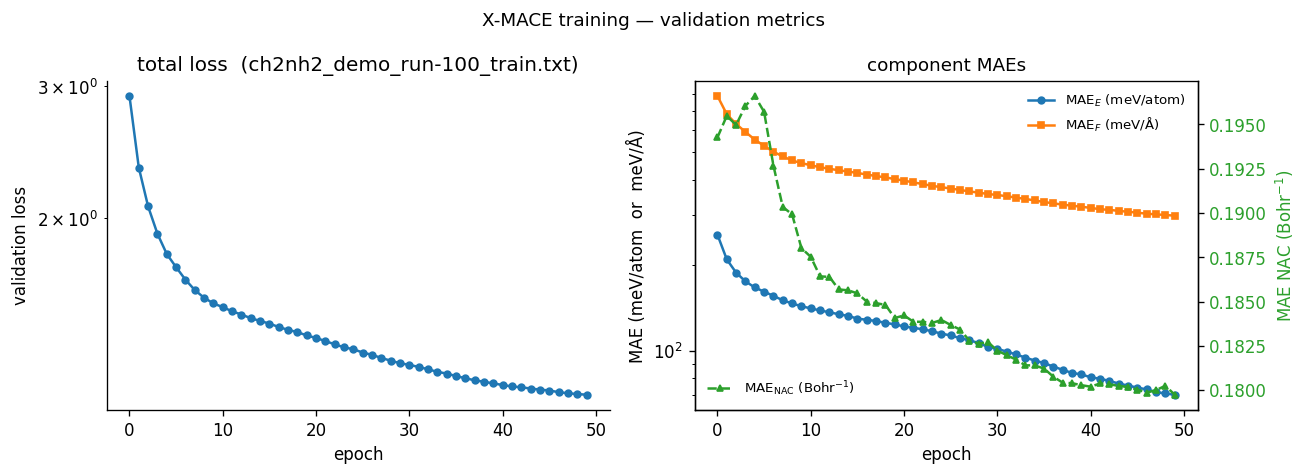

In [76]:
# ── Loading MACE model ────────────────────────────────────────────────────────────
MACE_3D = False
_candidates = (
    glob.glob("./results/ch2nh2_demo/checkpoints/*.model") +
    glob.glob("./results/**/checkpoints/*.model", recursive=True)
)
if _candidates and HAVE_XMACE:
    try:
        MACE_3D = _load_mace_model(sorted(_candidates)[-1])
    except Exception as _e:
        print(f"Could not load MACE model ({_e})")

# ── Learning curve ────────────────────────────────────────────────────────────
# Uses parse_learning_curve() from setup cell.

lc = parse_learning_curve()
ep, loss, mae_e, mae_f, mae_nac, src = lc
has_f   = not np.all(np.isnan(mae_f))
has_nac = not np.all(np.isnan(mae_nac))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

ax = axes[0]
ax.plot(ep, loss, 'o-', ms=4, lw=1.5)
ax.set_xlabel('epoch'); ax.set_ylabel('validation loss')
ax.set_title(f'total loss  ({os.path.basename(src)})')
ax.set_yscale('log')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.plot(ep, mae_e, 'o-', ms=4, lw=1.5, label='MAE$_E$ (meV/atom)')
if has_f:
    ax.plot(ep, mae_f, 's-', ms=4, lw=1.5, label='MAE$_F$ (meV/Å)')
if has_nac:
    ax2 = ax.twinx()
    ax2.plot(ep, mae_nac, '^--', ms=4, lw=1.5, color='C2',
                label='MAE$_{\\mathrm{NAC}}$ (Bohr$^{-1}$)')
    ax2.set_ylabel('MAE NAC (Bohr$^{-1}$)', color='C2', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='C2')
    ax2.legend(loc='lower left', fontsize=8, frameon=False)
ax.set_xlabel('epoch')
ax.set_ylabel('MAE (meV/atom  or  meV/Å)', fontsize=10)
ax.set_title('component MAEs', fontsize=11)
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=8, frameon=False)
ax.spines[['top']].set_visible(False)

plt.suptitle('X-MACE training — validation metrics', fontsize=11)
plt.tight_layout()
plt.show()

### Evaluating the model
The metric that matters for photodynamics is not the global MAE but the **error near the conical intersection**, because that region controls where and when trajectories hop. X‑MACE's `--error_table EnergyNacsDipoleMAE` reports energy/force/NAC MAEs per state. A parity plot (below, schematic unless you feed in real predictions) is the first sanity check; always follow it with a scan through the intersection region like the PES plot above.


Evaluating model on 1000 frames … 

  [MACE output keys]: ['energy', 'node_energy', 'contributions', 'nacs', 'socs', 'dipoles', 'forces', 'virials', 'stress', 'displacement', 'hessian', 'node_feats']
  [NAC] key='nacs' shape=(6, 3, 3) |raw|=1.1134
done.


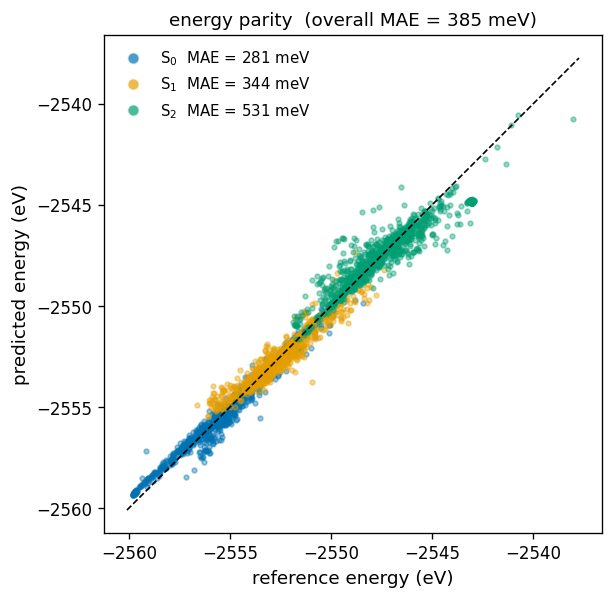

Per-state MAE:  S0 = 280.6 meV  S1 = 344.5 meV  S2 = 531.1 meV


In [77]:
# ── Parse reference energies and geometries ──────────────────────────────
_parity_frames = []
with open("./data/ch2nh2_with_forces.xyz") as _fh:
    _lines = _fh.read().splitlines()
_i = 0
while _i < len(_lines):
    if not _lines[_i].strip().isdigit(): _i += 1; continue
    _nat = int(_lines[_i].strip())
    _m = re.search(r'REF_energy="_JSON (\[\[.*?\]\])"', _lines[_i + 1])
    if _m is None: _i += 2 + _nat; continue
    _E = np.array(json.loads(_m.group(1))[0][:N_STATES])
    _R = np.array([[float(v) for v in _lines[_i + 2 + j].split()[1:]]
                    for j in range(_nat)])
    _parity_frames.append({"R": _R, "E": _E})
    _i += 2 + _nat

# ── Evaluate model on every geometry ─────────────────────────────────────
ref_all, pred_all = [], []
print(f"Evaluating model on {len(_parity_frames)} frames …", end=" ", flush=True)
for _fr in _parity_frames:
    try:
        E_pred, _, _ = _get_EF_mace(_fr["R"])
    except Exception:
        continue
    ref_all.append(_fr["E"])
    pred_all.append(E_pred)
print("done.")

ref_all  = np.array(ref_all)    # (N, 3) eV absolute
pred_all = np.array(pred_all)   # (N, 3) eV absolute

# ── Plot per-state parity ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.2, 5.2))
for k in range(N_STATES):
    ax.scatter(ref_all[:, k], pred_all[:, k], s=8, alpha=0.4,
                color=_COL[k], label=_LAB[k], rasterized=True)

lims = [min(ref_all.min(), pred_all.min()) - 0.3,
        max(ref_all.max(), pred_all.max()) + 0.3]
ax.plot(lims, lims, 'k--', lw=1)

mae_total = np.mean(np.abs(pred_all - ref_all)) * 1e3   # meV
mae_per_state = np.mean(np.abs(pred_all - ref_all), axis=0) * 1e3
ax.set_xlabel("reference energy (eV)", fontsize=11)
ax.set_ylabel("predicted energy (eV)", fontsize=11)
ax.set_title(f"energy parity  (overall MAE = {mae_total:.0f} meV)", fontsize=11)
ax.set_aspect('equal')

legend_labels = [f'{_LAB[k]}  MAE = {mae_per_state[k]:.0f} meV' for k in range(N_STATES)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=_COL[k],
            ms=7, alpha=0.7) for k in range(N_STATES)]
ax.legend(handles, legend_labels, fontsize=9, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()
print(f"Per-state MAE:  S0 = {mae_per_state[0]:.1f} meV  "
        f"S1 = {mae_per_state[1]:.1f} meV  S2 = {mae_per_state[2]:.1f} meV")


Reference geometry (S0 min):  φ = -0.0°
Torsion scan (181 points) … done.


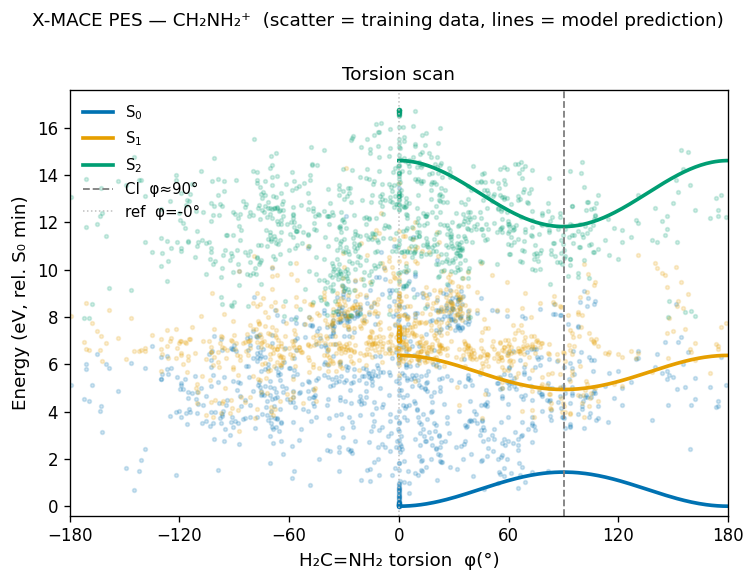

In [48]:
# ── PES visualization: X-MACE scans along key nuclear coordinates ─────────────
#
# Two one-dimensional scans through the trained PES.
#
#   (a) C=N torsion angle φ  (H–C=N–H dihedral, atoms 2-0-1-3)
#       The dominant photochemical coordinate: S1/S0 degeneracy appears
#       near φ ≈ 90° (conical intersection seam).
#
#   (b) C=N bond stretch  r(C=N)
#       Shows the electronic-state ordering across the bond-length space.
#
# Training-data points are overlaid as transparent scatter for validation
# (lines should pass through the cloud if the model fits well).
#
# Requires: provider cell executed first  (MACE_3D = True).
# ─────────────────────────────────────────────────────────────────────────────

# ── parse training set for reference scatter ──────────────────────────────────
_ref = []
with open("./data/ch2nh2_with_forces.xyz") as _fh:
    _lines = _fh.read().splitlines()
_i = 0
while _i < len(_lines):
    if not _lines[_i].strip().isdigit(): _i += 1; continue
    _nat = int(_lines[_i].strip())
    _m = re.search(r'REF_energy="_JSON (\[\[.*?\]\])"', _lines[_i+1])
    if _m is None: _i += 2 + _nat; continue
    _E = np.array(json.loads(_m.group(1))[0])
    _R = np.array([[float(v) for v in _lines[_i+2+j].split()[1:]] for j in range(_nat)])
    _ref.append({'E': _E, 'R': _R,
                  'phi': _dihedral_deg(_R, 2, 0, 1, 3),
                  'rCN': np.linalg.norm(_R[1]-_R[0]) * BOHR2ANG})
    _i += 2 + _nat

_ref_phi = np.array([d['phi'] for d in _ref])
_ref_E   = np.array([d['E']   for d in _ref])
_ref_E  -= _ref_E[:, 0].min()

# S0-minimum frame → reference geometry for scans
_i0   = int(np.argmin(_ref_E[:, 0]))
phi_ref  = _ref[_i0]['phi']
print(f"Reference geometry (S0 min):  φ = {phi_ref:.1f}°")

# ── Torsion scan ─────────────────────────────────────────────────────────
tor_frames = _read_scan_xyz("data/scan_torsion.xyz")
phi_vals = np.array([float(c.split("=")[1].split()[0]) for c, _ in tor_frames])
E_tor = np.zeros((len(tor_frames), N_STATES))
print(f"Torsion scan ({len(tor_frames)} points) …", end=" ", flush=True)
for k, (_, R) in enumerate(tor_frames):
    E_tor[k], _, _ = _get_EF_mace(R)
E_tor -= E_tor[:, 0].min()
print("done.")

# ── plot ──────────────────────────────────────────────────────────────────
_Emax = min(17.0, np.percentile(_ref_E[_ref_E < 50], 99))
for k in range(N_STATES):
    _mask = _ref_E[:, k] < _Emax
    plt.scatter(_ref_phi[_mask], _ref_E[_mask, k], s=5, alpha=0.18, color=_COL[k], rasterized=True)
for k in range(N_STATES):
    plt.plot(phi_vals, E_tor[:, k], color=_COL[k], lw=2.2, label=_LAB[k])
_ci_phi = phi_vals[int(np.argmin(E_tor[:, 1] - E_tor[:, 0]))]
plt.axvline(_ci_phi, color='0.50', ls='--', lw=1.1, label=f'CI  φ≈{_ci_phi:.0f}°')
plt.axvline(phi_ref, color='0.75', ls=':', lw=0.9, label=f'ref  φ={phi_ref:.0f}°')
plt.xlabel('H₂C=NH₂ torsion  φ(°)', fontsize=11)
plt.ylabel('Energy (eV, rel. S₀ min)', fontsize=11)
plt.title('Torsion scan', fontsize=11)
plt.xlim(-180, 180)
plt.xticks(range(-180, 181, 60))
plt.ylim(-0.4, _Emax * 1.05)
plt.legend(fontsize=9, frameon=False)

plt.suptitle('X-MACE PES — CH₂NH₂⁺  '        '(scatter = training data, lines = model prediction)', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()


Loaded 1000 frames with reference NACs
Computing MACE NACs on training set … done.


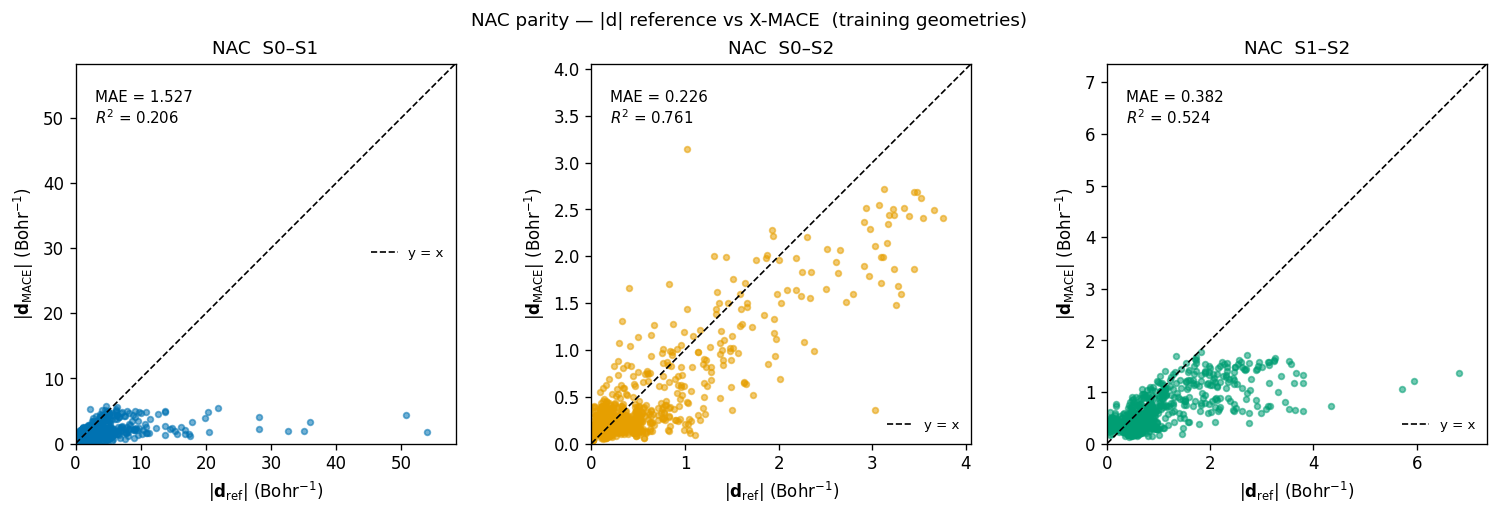

In [51]:
# ── NAC diagnostic: reference vs X-MACE NAC magnitudes ───────────────────────────────────
#
# For each frame in the training set computes:
#   |d_ref|  = Frobenius norm of reference NAC vector (one pair, all atoms)
#   |d_MACE| = same quantity from the trained model
#
# A parity scatter plot |d_MACE| vs |d_ref| for each of the 3 state pairs
# (S0-S1, S0-S2, S1-S2) reveals whether the model has learned NAC magnitudes.
# Points on y = x = perfect agreement.
# ─────────────────────────────────────────────────────────────────────────────
_PAIR_LABELS = ['S0–S1', 'S0–S2', 'S1–S2']
_PAIR_IDX    = [(0, 1), (0, 2), (1, 2)]

# ── Parse training frames with NAC labels ────────────────────────────────────────────
_nac_frames = []
with open('./data/ch2nh2_with_forces.xyz') as _fh:
    _ls = _fh.read().splitlines()
_i = 0
while _i < len(_ls):
    if not _ls[_i].strip().isdigit(): _i += 1; continue
    _nat = int(_ls[_i].strip())
    _hdr = _ls[_i + 1]
    _mE = re.search(r'REF_energy="_JSON (\[\[.*?\]\])"', _hdr)
    _mN = re.search(r'REF_nacs="_JSON (\[.*?\])"', _hdr)
    if _mE is None or _mN is None:
        _i += 2 + _nat; continue
    _R = np.array([[float(v) for v in _ls[_i+2+j].split()[1:]] for j in range(_nat)])
    # REF_nacs stored as (n_atoms, n_pairs, 3) -> transpose to (n_pairs, n_atoms, 3)
    _nac_raw = np.array(json.loads(_mN.group(1)))
    if _nac_raw.ndim == 3 and _nac_raw.shape == (_nat, 3, 3):
        _nac_ref = _nac_raw.transpose(1, 0, 2)   # (n_pairs, n_atoms, 3)
    else:
        _i += 2 + _nat; continue
    _nac_frames.append({'R': _R, 'nac_ref': _nac_ref})
    _i += 2 + _nat
print(f'Loaded {len(_nac_frames)} frames with reference NACs')

# ── Evaluate MACE on every training geometry ───────────────────────────────────────
_ref_mag  = [[] for _ in _PAIR_IDX]
_mace_mag = [[] for _ in _PAIR_IDX]

print('Computing MACE NACs on training set …', end=' ', flush=True)
_n_zero = 0
for _fr in _nac_frames:
    try:
        _, _, _D = _get_EF_mace(_fr['R'])    # D: (n_states, n_states, n_atoms, 3)
    except Exception:
        continue
    if not np.any(_D != 0.0):
        _n_zero += 1
    for _pk, (_si, _sj) in enumerate(_PAIR_IDX):
        _ref_mag [_pk].append(float(np.sqrt(np.sum(_fr['nac_ref'][_pk]**2))))
        _mace_mag[_pk].append(float(np.sqrt(np.sum(_D[_si, _sj]**2))))
print('done.')

# ── Plot ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for _pk, (ax, label, col) in enumerate(zip(axes, _PAIR_LABELS, _COL)):
    _xv = np.array(_ref_mag [_pk])
    _yv = np.array(_mace_mag[_pk])
    ax.scatter(_xv, _yv, s=12, alpha=0.55, color=col, rasterized=True)
    _lim = max(float(_xv.max()) if len(_xv) else 0,
                float(_yv.max()) if len(_yv) else 0, 1e-6) * 1.08
    ax.plot([0, _lim], [0, _lim], 'k--', lw=1.0, label='y = x')
    ax.set_xlabel(r'$|\mathbf{d}_\mathrm{ref}|$ (Bohr$^{-1}$)', fontsize=10)
    ax.set_ylabel(r'$|\mathbf{d}_\mathrm{MACE}|$ (Bohr$^{-1}$)', fontsize=10)
    ax.set_title(f'NAC  {label}', fontsize=11)
    ax.set_xlim(0, _lim); ax.set_ylim(0, _lim)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, frameon=False)
    if len(_xv) > 1:
        _mae = float(np.mean(np.abs(_xv - _yv)))
        _r2  = float(np.corrcoef(_xv, _yv)[0, 1])**2
        ax.text(0.05, 0.93,
                f'MAE = {_mae:.3f}\n$R^2$ = {_r2:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')

plt.suptitle('NAC parity — |d| reference vs X-MACE  (training geometries)', fontsize=11)
plt.tight_layout()
plt.show()

## Part 5 — Nonadiabatic dynamics: trajectory surface hopping

We now propagate nuclei and let them **hop** between surfaces. The standard method is **Tully's fewest‑switches surface hopping (FSSH)**:

1. Propagate the nuclei classically on the **active** surface (velocity Verlet).
2. Propagate the electronic amplitudes $c_k$ with the time‑dependent Schrödinger equation, coupled through $\sigma_{kj} = \dot{\mathbf R}\cdot\mathbf d_{kj}$ (velocity · NAC).
3. Each step, compute the **fewest‑switches** hopping probability to every other state; draw a random number; hop if selected.
4. On a hop, **rescale the velocity** along the NAC to conserve total energy (reject "frustrated" hops that lack the energy).
5. Apply a **decoherence** correction (real FSSH over‑coheres without it).

**Where the ML model enters:** at every step FSSH needs $E_k(\mathbf R)$, forces $-\nabla E_k$, and the couplings $\mathbf d_{kj}$ — exactly the quantities X‑MACE predicts. In production you wire the trained model into a driver such as **SHARC** / **PySHARC** (or `pysurf`), which handles ensembles, sampling and analysis.


In [52]:
# ── FSSH dispatch ─────────────────────────────────────────────────────────────
# All FSSH integrators (run_fssh_3d, run_fssh_1d) are defined in the setup cell.
# Here we just select which one to use based on the backend.

if MACE_3D:
    run_fssh = run_fssh_3d
    print('run_fssh → 3D FSSH, 18 nuclear DOF')
    print('  Hopping: Tully (NAC from model) if NAC output ≠ 0, else Landau-Zener')
else:
    run_fssh = run_fssh_1d
    print('run_fssh → 1D torsion FSSH (fallback, exact analytical NAC)')


run_fssh → 3D FSSH, 18 nuclear DOF
  Hopping: Tully (NAC from model) if NAC output ≠ 0, else Landau-Zener


Running 80 trajectories (3D MACE) …
[step 0 diag]  |D| = 0.7455 Bohr⁻¹  |SIG| = 0.0032 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.218 eV  cvec = [0. 0. 1.]
[step 0 diag]  |D| = 0.8330 Bohr⁻¹  |SIG| = 0.0379 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.305 eV  cvec = [1.e-04 1.e-04 1.e+00]
[step 0 diag]  |D| = 0.8979 Bohr⁻¹  |SIG| = 0.0134 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.286 eV  cvec = [0.e+00 1.e-04 1.e+00]
[step 0 diag]  |D| = 0.8200 Bohr⁻¹  |SIG| = 0.0109 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.248 eV  cvec = [0.e+00 1.e-04 1.e+00]
[step 0 diag]  |D| = 0.7216 Bohr⁻¹  |SIG| = 0.0031 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.267 eV  cvec = [0. 0. 1.]
[step 0 diag]  |D| = 0.8085 Bohr⁻¹  |SIG| = 0.0066 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.275 eV  cvec = [0.e+00 1.e-04 1.e+00]
[step 0 diag]  |D| = 1.0710 Bohr⁻¹  |SIG| = 0.0073 fs⁻¹  USE_TULLY = True
               |E_gap(S0-S1)| = 6.471 

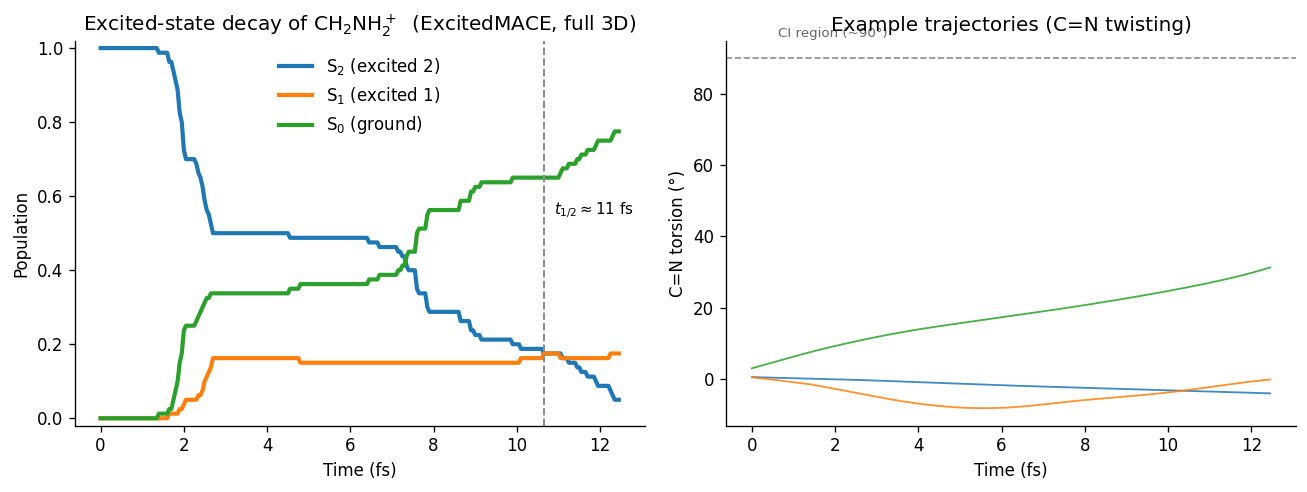

Isomerized on S₀ (product basin): 4%  (branching at the conical intersection)
Saved NumPy archive  →  ./outputs/last_traj.npz
Saved XYZ trajectory →  ./outputs/last_traj.xyz
  250 frames, atoms: ['C', 'N', 'H', 'H', 'H', 'H'], positions in Å


In [53]:

# ── Run ensemble and plot photochemistry results ───────────────────────────────
#
# 3D mode: N_TRAJ x NSTEPS-step trajectories, dt=0.1 fs -> 200 fs per traj (loose Berendsen thermostat).
#
# ─────────────────────────────────────────────────────────────────────────────

N_TRAJ = 80
NSTEPS = 250
DT = 0.05         # fs (Berendsen+VV)

T_ax      = None
pop_S0    = None
pop_S1    = None
pop_S2    = None
examples  = []       # a few trajectories for the torsion plot
n_iso     = 0

print(f"Running {N_TRAJ} trajectories ({'3D MACE' if MACE_3D else '1D fallback'}) …")
for s in range(N_TRAJ):
    t, R_traj, phi, act, E_traj = run_fssh(seed=s, nsteps=NSTEPS, start_state=2, dt=DT)

    if T_ax is None:
        T_ax   = t
        pop_S0 = np.zeros_like(t, float)
        pop_S1 = np.zeros_like(t, float)
        pop_S2 = np.zeros_like(t, float)
    pop_S0 += (act == 0).astype(float)
    pop_S1 += (act == 1).astype(float)
    pop_S2 += (act == 2).astype(float)

    phi_final = phi[-1] % 360
    if act[-1] == 0 and (90 < phi_final < 270):
        n_iso += 1
    if s < 3:
        examples.append((t, phi, act))
    # capture every trajectory (3D) for saving; overwrite each loop → last one kept
    _last_t, _last_R, _last_phi, _last_act, _last_E = t, R_traj, phi, act, E_traj

pop_S0 /= N_TRAJ
pop_S1 /= N_TRAJ
pop_S2 /= N_TRAJ

# Half-life of the excited state
half_idx = np.argmin(np.abs(pop_S1 - 0.5))
t_half   = T_ax[half_idx]
print(f"Done.  Excited-state half-life: ~{t_half:.1f} fs")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
title_sfx  = "(ExcitedMACE, full 3D)" if MACE_3D else "(1D torsion model)"

# (1) State populations
axes[0].plot(T_ax, pop_S2, lw=2.5, label=r'S$_2$ (excited 2)')
axes[0].plot(T_ax, pop_S1, lw=2.5, label=r'S$_1$ (excited 1)')
axes[0].plot(T_ax, pop_S0, lw=2.5, label=r'S$_0$ (ground)')
axes[0].axvline(t_half, color='0.55', ls='--', lw=1.2)
axes[0].text(t_half + T_ax[-1]*0.02, 0.55, rf'$t_{{1/2}}\approx${t_half:.0f} fs', fontsize=9)
axes[0].set_xlabel('Time (fs)'); axes[0].set_ylabel('Population')
axes[0].set_title(f'Excited-state decay of CH$_2$NH$_2^+$  {title_sfx}')
axes[0].legend(frameon=False); axes[0].set_ylim(-0.02, 1.02)
axes[0].spines[['top','right']].set_visible(False)

# (2) Example torsion trajectories
for t_ex, phi_ex, act_ex in examples:
    axes[1].plot(t_ex, phi_ex, lw=1.1, alpha=0.85)
axes[1].axhline(90, color='0.55', ls='--', lw=1)
axes[1].text(T_ax[-1]*0.05, 96, 'CI region (~90°)', fontsize=8, color='0.4')
axes[1].set_xlabel('Time (fs)'); axes[1].set_ylabel('C=N torsion (°)')
axes[1].set_title('Example trajectories (C=N twisting)')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Isomerized on S₀ (product basin): {100*n_iso/N_TRAJ:.0f}%  "
      f"(branching at the conical intersection)")

# ── Save last trajectory ───────────────────────────────────────────────────────────────────────
# — NumPy archive (all arrays, lossless) —
_npz_path = './outputs/last_traj.npz'
np.savez_compressed(
    _npz_path,
    t        = _last_t,       # (nsteps,)            fs
    R        = _last_R,       # (nsteps, n_atoms, 3) Bohr
    phi      = _last_phi,     # (nsteps,)            degrees
    active   = _last_act,     # (nsteps,)            state index
    energies = _last_E,       # (nsteps, n_states)   eV
)
print(f'Saved NumPy archive  →  {_npz_path}')

# — Extended XYZ trajectory (readable by ASE / OVITO / VMD) —
_SYMS = ['C', 'N', 'H', 'H', 'H', 'H']
_xyz_path = './outputs/last_traj.xyz'
with open(_xyz_path, 'w') as _fxyz:
    for _step in range(len(_last_t)):
        _R_ang = _last_R[_step] * BOHR2ANG   # convert Bohr → Å
        _fxyz.write(f'{len(_SYMS)}\n')
        _fxyz.write(
            f'step={_step} t={_last_t[_step]:.3f} fs '
            f'active_state={_last_act[_step]} '
            f'phi={_last_phi[_step]:.2f} deg '
            + ' '.join(f'E_{k}={_last_E[_step,k]:.4f}eV' for k in range(N_STATES))
            + '\n')
        for _sym, (_x, _y, _z) in zip(_SYMS, _R_ang):
            _fxyz.write(f'{_sym}  {_x:.6f}  {_y:.6f}  {_z:.6f}\n')
print(f'Saved XYZ trajectory →  {_xyz_path}')
print(f'  {len(_last_t)} frames, atoms: {_SYMS}, positions in Å')

### Reading the result
Two features carry the photochemistry:

- **The population curve falls within ~50 fs.** That is *ultrafast internal conversion*: the excited molecule funnels to the ground state through the S1/S0 conical intersection, far faster than fluorescence. This is the hallmark of CH2NH2+ (and of the retinal chromophore it models).
- **The branching.** Trajectories that pass the twisted intersection split between falling back to the reactant and continuing to the **isomerized** product — the molecular event behind vision, photoswitches, and many photoreactions.

A note on the model: with a **single** torsional coordinate there is nowhere for the excess energy to go, so we added a light Langevin friction to stand in for **intramolecular vibrational energy redistribution** (the flow into the other $3N-6$ modes). The *real* X‑MACE model carries all those modes explicitly, so this surrogate is unnecessary in production — the decay becomes irreversible on its own.


## References & pointers

- Barrett, Ortner, Westermayr, *Transferable Machine Learning Potential X‑MACE for Excited States using Integrated DeepSets*, arXiv:2502.12870 (2025). Code: `github.com/rhyan10/X-MACE`.
- Batatia *et al.*, *MACE: Higher Order Equivariant Message Passing Neural Networks*, NeurIPS (2022). `github.com/ACEsuit/mace`.
- Westermayr, Gastegger, Marquetand, *Combining SchNet and SHARC: the SchNarc approach*, J. Phys. Chem. Lett. **11**, 3828 (2020).
- Westermayr & Marquetand, *Machine Learning for Electronically Excited States of Molecules*, Chem. Rev. **121**, 9873 (2021).
- Tully, *Molecular dynamics with electronic transitions*, J. Chem. Phys. **93**, 1061 (1990) — the original FSSH.
- Mai, Marquetand, González, *Nonadiabatic dynamics: SHARC*, WIREs Comput. Mol. Sci. **8**, e1370 (2018).
- Datasets: X‑MACE figshare `28425173`; "Surface Hopping Nested Instances" training set, Sci. Data (2025).

*Built as a teaching notebook: the theory, data‑visualization and surface‑hopping cells run offline; the X‑MACE training/inference cells are the production path.*
